Nepse Repplit Word Cloud

In [ ]:
!pip install wordcloud matplotlib pandas nltk

Step-1 : importing the Libiary

In [ ]:
import pandas as pd
import re
import unicodedata
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

Step-2 Load the CSV data

In [ ]:
df = pd.read_csv("/content/all_nepse.csv")

# Combine title and post body into one column
df["combined"] = df["title"].fillna("") + " " + df["selftext"].fillna("")

print(f"Total posts: {len(df)}")
print(df["combined"].head(3))

Total posts: 1802
0    Adsense Approval Services Is there anyone who ...
1    Resorts in Nepal with a river side Hello, I am...
2    anyone available for phone call lets just hang...
Name: combined, dtype: object


Step-3::
Define cleaning functions

In [ ]:
def clean_text(text):
    text = text.lower()                                      # lowercase
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)     # remove URLs
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text) # remove emails
    text = re.sub(r"<[^>]+>", " ", text)                     # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()                 # remove extra spaces
    return text

Step-4 ::
Define stopwords

In [ ]:
STOPWORDS = {
    # English
    "the","is","am","are","a","an","in","on","at","and","of","to",
    "this","that","it","for","with","was","be","have","has","not",
    "but","from","as","by","they","we","you","your","my","i","he",
    "she","his","her","our","their","do","did","will","can","get",
    "got","its","been","all","would","could","should","if","or",
    "so","me","him","us","them","about","after","just","up","out",
    "no","more","what","how","any","there","some","when","also",
    "than","who","which","then","these","those","had","were","like","please","keep"
    "only","very","even","over","each","much","most","two","one",
    "may","well","now","see","here","while","back","new","still",
    "first","good","going","need","don","com","https","www","amp","k","m","etc","go","t",

    # Reddit/forum noise
    "anyone","know","help","please","post","thread","guy",
    "ask","want","use","regarding","always","another","day","time","year",

    # Romanized Nepali
    "hola","nai","ani","lai","ma","xa","ra","ko","ki","ta","yo",
    "le","cha","ho","hai","garna","bhayo","bhane","gardai",
    "garnu","huncha","chha","pani","timro",
}

Step5: Apply cleaning to all posts

In [ ]:
cleaned = df["combined"].apply(clean_text)

# Join all cleaned posts into one big text string
all_text = " ".join(cleaned.tolist())

# Preview
print(f"Total characters: {len(all_text):,}")
print("Sample:", all_text[:300])

Total characters: 464,307
Sample: adsense approval services is there anyone who can get an adsense approval for my site ready to pay significant amount or anyone who is willing to sell their approved site for reasonable price resorts in nepal with a river side hello i am planning to travel outside valley for few days to a resort wit


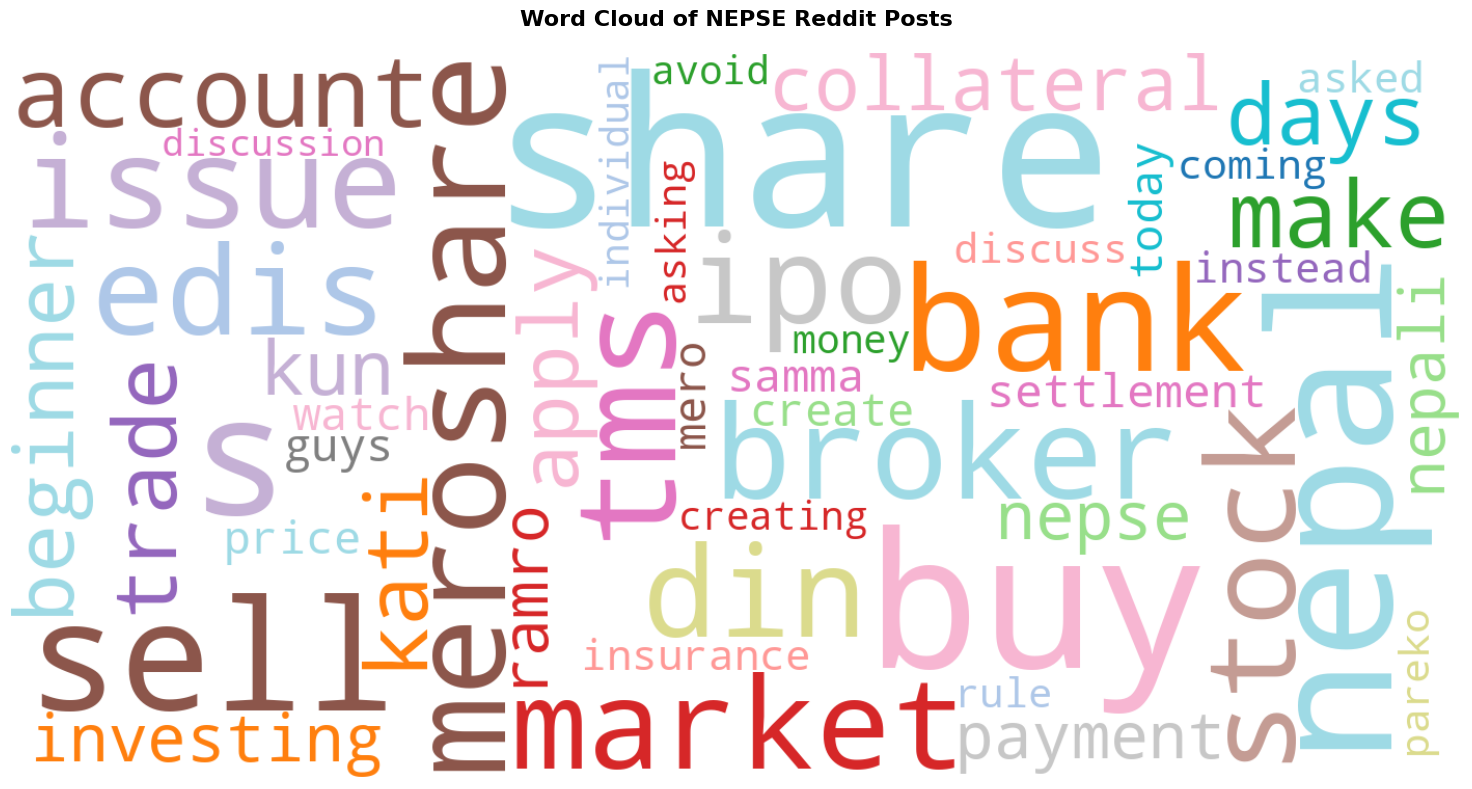

Saved: nepse_wordcloud.png


In [ ]:
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=50,
    colormap="tab20",       # gives many colors like your reference image
    collocations=False,     # avoid repeating bigrams
    min_font_size=10,
    max_font_size=200
).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of NEPSE Reddit Posts", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("nepse_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: nepse_wordcloud.png")

Insight

The refined word cloud of NEPSE-related Reddit posts highlights that user discussions are heavily centered around core trading activities and market participation. Dominant terms such as stock, trade, broker, price, and account indicate that most users are actively engaged in buying and selling shares, managing brokerage accounts, and tracking price movements. This suggests that the platform is widely used by retail investors seeking practical information about trading processes, transaction systems (like TMS), and overall market behavior rather than long-term financial theory.

Additionally, the presence of contextual words like problem, creating, buy, sell, and market reflects that many users are facing operational or technical challenges, especially related to account setup, transactions, and system usage. After removing common filler and non-informative words, the visualization becomes more focused, revealing genuine user concerns and interests. Overall, the insights suggest that NEPSE Reddit discussions are largely driven by real-time trading needs, user issues, and market interaction, making it a valuable source for understanding retail investor behavior.